# Programming exercise 4: Coupled oscillators

Due on Monday, 11.05.26, 20.00h

## The problem

Consider two coupled harmonic oscillators described by the Hamiltonian
$$
H=H_1 + H_2 + V =\frac{1}{2m}(p_1^2 + p_2^2) + \frac{1}{2}k(x_1^2 + x_2^2) + \frac{1}{2}\lambda(x_1 - x_2)^2
$$
We want to calculate the eigenvalues and eigenfunctions of this Hamiltonian and compare its dynamics to the dynamics of the corresponding classical problem. This problem is exactly solvable by transforming into center of mass and relative coordinates. However, as an exercise on how basis set expansion methods work, we want to treat the coupling term lambda as a perturbation and solve the problem by expanding into eigenfunctions of the uncoupled 2D harmonic oscillator and diagonalizaing the resulting Hamiltonian.

In [177]:
# load standard libraries

import numpy as np   # standard numerics library
import numpy.linalg as LA

import matplotlib.pyplot as plt   # for making plots

import time as time

import scipy as sc
import scipy.sparse as sp
import scipy.sparse.linalg as spla

from ipywidgets import interactive

import Comp_Quant_Dynam as cqd

from matplotlib import animation
from IPython.display import HTML

from dataclasses import dataclass

### Exercise 1

Transforming into center of mass and relative coordinates (normal modes)

$$
x_{CM}=(x_1+x_2)/2 \\
x_{rel}=(x_1-x_2)
$$ 
the Hamiltonian becomes

$$
H=\frac{p_{CM}^2}{2M}+\frac{p_{rel}^2}{2\mu} + \frac{1}{2}k_{CM}x_{CM}^2 + \frac{1}{2}k_{rel}x_{rel}^2 
$$
with $M=2m$, $\mu=m/2$, $k_{CM}=2k$, $k_{rel}=k/2+\lambda$. Thus the problem separates into two independent oscillators with frequencies 
$$
\omega_{CM} = \sqrt{\frac{k_{CM}}{M}} =\sqrt{\frac{k}{m}} =\omega \\
\omega_{rel} = \sqrt{\frac{k_{rel}}{\mu}} = \omega\sqrt{1+2\lambda/k}
$$
With this, one can write down the solution of the problem in the new coordinates as
$$
x_{CM}(t) = A_{CM} \cos(\omega t)+B_{CM} \sin(\omega t) \\
x_{rel}(t) = A_{rel} \cos(\omega_{rel} t)+B_{rel} \sin(\omega_{rel} t)
$$

Solve the classical problem for initial conditions $\{x_1(t=0)=x_{10}, x_2(t=0)=x_{20}, \dot{x}_1(t=0)=v_{10}, \dot{x}_2(t=0)=v_{20}\}$. For this, transform the initial conditions into CM and rel coordinates, determine the A,B coefficients and transform back to the original coordinates $x_1$, $x_2$. You don't have to document this calculation here but just plot the classical trajectories (i.e., plot the positions of the two particles as a function of time) for $m=k=1,\lambda=0.2$ and ${x_{10}=1,x_{20}=v_{10}=v_{20}=0}$ up to a time $t_f=50$. Observe the beating between center-of-mass and relative frequency.

Optional: It is also instructive to make a density plot of the potential as a function of $x_1$ and $x_2$ and plot the classical trajectory on top of it.

Very instructive 2D plotting tips:
https://jakevdp.github.io/PythonDataScienceHandbook/04.04-density-and-contour-plots.html


In [178]:
def V(x1, x2, k=1, l=0.2):
    return k * (x1**2 + x2**2) / 2 + l * (x1 - x2)**2 / 2

def x1_x2(t, x10, x20, v10, v20, m=1, k=1, l=0.2):
    wcm = np.sqrt(k / m)
    wrel = wcm * np.sqrt(1 + 2 * l / k)

    xcm = (x10 + x20) / 2 * np.cos(wcm * t) + (v10 + v20) / (2 * wcm) * np.sin(wcm * t)
    xrel = (x10 - x20) * np.cos(wrel * t) + (v10 - v20) / wrel * np.sin(wrel * t)

    x1_t = xcm + xrel / 2
    x2_t = xcm - xrel / 2
    
    return x1_t, x2_t

t = np.linspace(0, 50, 500)
x1, x2 = x1_x2(t, 1, 0, 0, 0)

Text(0, 0.5, 'x')

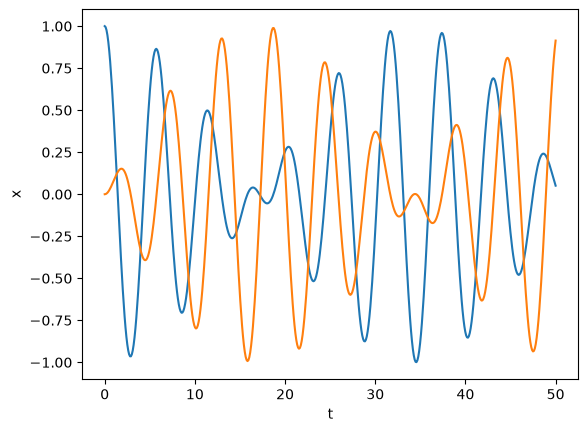

In [179]:
plt.plot(t, x1, label='x1(t)')
plt.plot(t, x2, label='x2(t)')

plt.xlabel('t')
plt.ylabel('x')

Text(0, 0.5, 'x2')

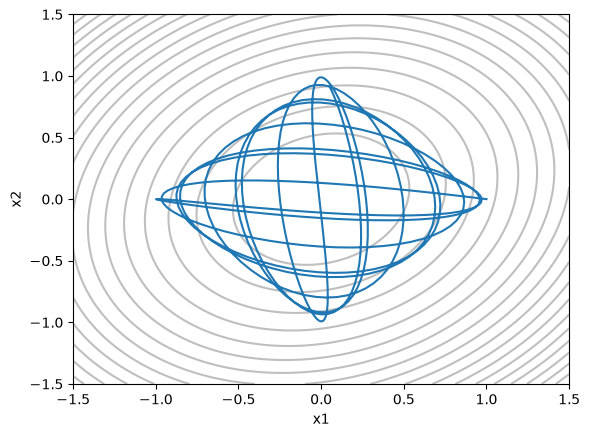

In [180]:
L = 1.5
X1, X2 = np.meshgrid(
    np.linspace(-L, L, 100),
    np.linspace(-L, L, 100)
)
Vval = V(X1, X2)
levels = np.linspace(np.min(Vval), np.max(Vval), 20)

plt.contour(X1, X2, Vval, levels=levels, colors='gray', alpha=0.5)
plt.plot(x1, x2, label='trajectory')

plt.xlabel('x1')
plt.ylabel('x2')

### Exercise 2

The exact eigenenergies can be read off from the Hamiltonian in CM and rel coordinates as the problem separates.
$$
E(n_{CM},n_{rel}) = (n_{CM}+1/2) \hbar \omega_{CM}+ (n_{rel}+1/2)\hbar \omega_{rel}
$$
The ground state energy is just $E_0 = E(0,0) = \frac{1}{2} \hbar (\omega_{CM}+\omega_{rel})=\frac{\hbar\omega}{2}(1+\sqrt{1+2\lambda/k})$.
We will use this analytical result to test the correctness and convergence of the basis set expansion approach we are going to employ now.

We want to expand the Hamiltonian in the eigenbasis of the 2D harmonic oscillator (use the same basis size $N_1=N_2=N_{max}$ for both oscillator modes 1 and 2. What is the resulting size of the basis set?). 
For this, one can expand the perturbation term $\frac{1}{2}\lambda(x_1 - x_2)^2$ into ladder operators and then apply it to the unperturbed basis states. Recall $x/x_{HO} = (a^\dagger + a)/\sqrt{2}$ and work in dimensionless units where $x_{HO}=1$.
How many off-diagonal elements will there be in each line? 

There are many ways of building the Hamiltonian matrix in the chosen basis. First, make sure you understand what the basis states are and how one would order them in a reasonable way.  
A fail-safe way to build up the Hamiltonian matrix is to iterate over all states of the chosen basis and determine the matrix-elments it couples to. We have provided the function `cqd.hamiltonians.build_H_coupled_HO_man(N1, N2, lam)` as a reference for you. Another, arguably more elegant, way which you are supposed to do is to build the matrix representing the annihilation operator on the Hilbert space of one of the oscillators. The creation operator is then simply the transpose of that and the position operator can be built by adding the two. We have a 2D problem so we work in a Hilbert space that is a tensor product of the two Hilbert spaces of the oscillators. Thus, to represent the position operator $\hat{x}_1$ acting on oscillator 1 in the full Hilbert space we have to use $\hat{x}_1 \otimes \mathbf{1}$, where $\mathbf{1}$ is the identity acting on the second oscillator. This can be achieved by using a Kronecker product. For multiplying or squaring operators you can use the numpy dot product function. Alternatively you can make use of the matrix multiplication operator `@`.

</div>
The second method has the advantage that it requires only to build one operator explicitly and the rest is matrix algebra (or two if you use different basis sizes for the two oscillators). Using sparse matrices this process can be very efficient.
Technical note of caution: The two described methods for building the Hamiltonian matrix might lead to slightly different results due to effects of the finite basis size. This will not affect the convergence of low lying eigenstates.

Diagonalize the Hamiltonian (built in both ways) and check your result by comparing the ground state energy to the exact result. How small can you make the basis such that the ground state energy is still converged? (You should find that $N_1=N_2=5$, i.e. 25 basis states, is sufficient to get the ground state with good precision up to $\lambda=2$.) Also look at some excited states, at least the lowest 6, make sure that your diagonalization results agree with the exact one, and understand the structure of the spectrum. Plot the eigenenergies for a grid of $\lambda$ values from 0 to 2.

Optional: As this problem can be solved analytically, we are complicating it by doing the basis set expansion. However, one could now use this method to apply it to non-integrable cases like a quartic (non-linear) coupling or even the quantum version of the Henon-Heiles problem, which does not separate and is classically chaotic!
If you want to go beyond, try other potentials!


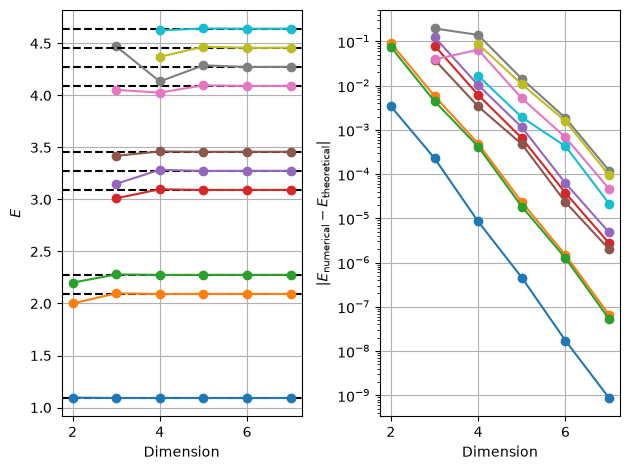

In [181]:

@dataclass
class HamiltonianData:
    H: any
    a1: any
    a1d: any
    a2: any
    a2d: any
    D: int

def make_H(m=1, k=1, l=0.2, DIM=10, Hint=None):
    def Hint_default(x1, x2):
        return (x1 - x2) @ (x1 - x2) / 2
    if Hint == None:
        Hint = Hint_default

    w = np.sqrt(k / m)
    a = sp.diags([np.sqrt(np.arange(1, DIM))], [1], shape=(DIM, DIM))

    a1 = sp.kron(a, sp.eye(DIM))
    a1d = a1.getH()
    x1 = np.sqrt(1 / (2 * m * w)) * (a1 + a1d)

    a2 = sp.kron(sp.eye(DIM), a)
    a2d = a2.getH()
    x2 = np.sqrt(1 / (2 * m * w)) * (a2 + a2d)

    H1 = m * w * (a1d @ a1 + sp.eye(DIM**2) / 2)
    H2 = m * w * (a2d @ a2 + sp.eye(DIM**2) / 2)
    H = H1 + H2 + l * Hint(x1, x2)
    return HamiltonianData(H, a1, a1d, a2, a2d, DIM)

def solve_H(H, k=None):
    if k is None: k = H.shape[0] - 1
    else: k = min(k, H.shape[0] - 1)
    eigval, eigvec = spla.eigsh(H, k=k, which='SM')
    idx = np.argsort(eigval)
    return eigval[idx], eigvec[:, idx]

def theoretical_E(ncm, nrel, m=1, k=1, l=0.2):
    wcm = np.sqrt(k / m)
    wrel = wcm * np.sqrt(1 + 2 * l / k)
    return m * wcm * (ncm + 0.5) + m * wrel * (nrel + 0.5)


dims = np.arange(2, 8)
levels = 10
evals = np.empty((len(dims), levels))
evals[:] = np.nan

for i, dim in enumerate(dims):
    H = make_H(DIM=dim).H
    eigval, _ = solve_H(H, k=levels)
    evals[i,:len(eigval)] = eigval

fig, (axval, axerr) = plt.subplots(1, 2)
ncm, nrel = np.meshgrid(np.arange(levels), np.arange(levels))
tE = np.sort(theoretical_E(ncm, nrel).ravel())

for i, eval in enumerate(evals.T):
    axval.axhline(tE[i], ls='--', c='k')
    axval.plot(dims, eval, 'o-')
    axerr.plot(dims, np.abs(eval - tE[i]), 'o-')

axval.grid()
axerr.grid()

axval.set_xlabel('Dimension')
axval.set_ylabel('$E$')
axerr.set_xlabel('Dimension')
axerr.set_ylabel('$|E_{\\mathrm{numerical}} - E_{\\mathrm{theoretical}}|$')
axerr.set_yscale('log')

fig.tight_layout()

(<Figure size 640x480 with 1 Axes>, <Axes: xlabel='$\\lambda$', ylabel='$E$'>)

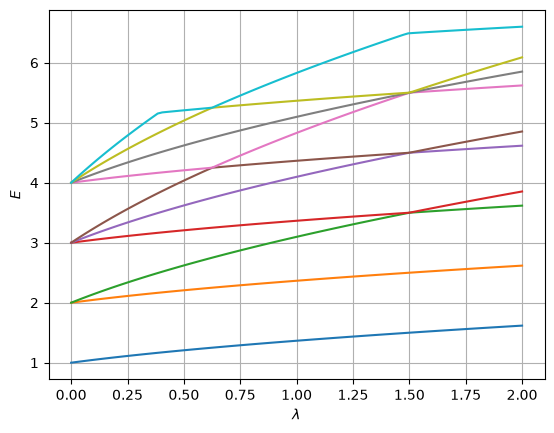

In [182]:
ls = np.linspace(0, 2, 100)

def lambdas_plot(l, Hint=None, DIM=10, levels=levels):
    evals = np.empty((len(ls), levels))
    evals[:] = np.nan

    for i, l in enumerate(ls):
        H = make_H(l=l, Hint=Hint, DIM=DIM).H
        eigval, _ = solve_H(H, k=levels)
        evals[i,:len(eigval)] = eigval

    fig, ax = plt.subplots()

    for i, eval in enumerate(evals.T):
        ax.plot(ls, eval)

    axval.grid()
    axerr.grid()

    ax.set_xlabel('$\\lambda$')
    ax.set_ylabel('$E$')
    ax.grid()

    return fig, ax

lambdas_plot(ls)

(<Figure size 640x480 with 1 Axes>, <Axes: xlabel='$\\lambda$', ylabel='$E$'>)

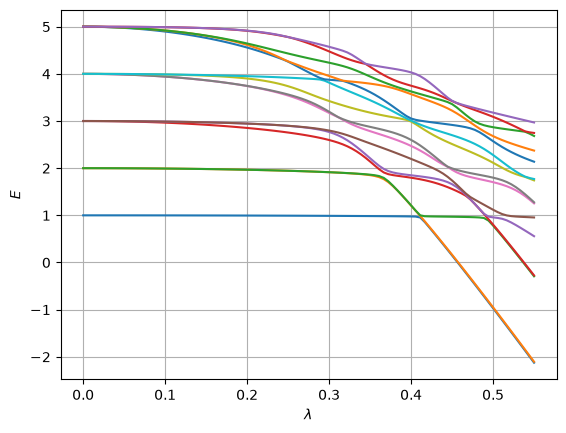

In [183]:
def H_Hennon_Heiles(x1, x2):
    return x1 @ x1 @ x2 - x2 @ x2 @ x2 / 3

ls = np.linspace(0, 0.55, 100)
lambdas_plot(ls, Hint=H_Hennon_Heiles, DIM=10, levels=15)

### Exercise 3 (optional)

Calculate the time evolution for different initial conditions (as on exercise sheet 2) using the eigenstates obtained in exercise 2. Try the following initial states: 1) oscillator 1 in the first excited state, oscillator two in its ground state $|0\rangle$; 2) oscillator 1 in $|\psi_0\rangle = (|0\rangle+|1\rangle)/\sqrt(2)$, oscillator two in state $|0\rangle$;  3) oscillator 1 in a coherent state (e.g. with $\langle n \rangle = |\alpha|^2 = 2$) and oscillator 2 in $|0\rangle$. Example parameters: $\lambda=0.2$, $N_1=N_2=10$, $t_f = 40$.

Monitor the dynamics by calculating $\langle x_1 \rangle$ and $\langle x_2 \rangle$. Compare your observations to the classical expectation: propagate a classical particle with $x_{i0}=\langle x_i(t=0) \rangle$ and $p_{i0}=\langle p_i(t=0) \rangle$. Describe and interpret your observations.

Calculate also the energy expectation value of each oscillator, as well as the probabilities for each oscillator to be in state $|n\rangle$. You should observe that the energy fluctuates between the oscillators.

Represent the wave function on a 2D spatial grid using the exact harmonic oscillator eigenfunctions (Hermite Polynomials...). Animate the time-dependence of the wave packet in a 2D density plot.

In [184]:
Hdat = make_H()
H = Hdat.H
evals, evecs = solve_H(H, 15)
print(type(evecs))

def get_ho_wf(n, k=1, m=1):
    w = np.sqrt(k / m)
    def ho_wf(x):
        return (m*w)**(1/4) * sc.special.hermite(n)(np.sqrt(m*w)*x) * np.exp(-m*w*x**2/2) / np.sqrt(2**n * sc.special.factorial(n) * np.sqrt(np.pi))
    return ho_wf


SPACE_DIM = 10
BOX = 10
x = np.arange(-BOX/2, BOX/2, 0.2)
dx = x[1] - x[0]
wfs = np.zeros((x.size, SPACE_DIM))
for i in range(SPACE_DIM):
    wfs[:, i] = get_ho_wf(i)(x)


def to_space(state, N=10):
    space = np.zeros((x.size, x.size), dtype=complex)
    for i, c in enumerate(state):
        n1 = i // N
        n2 = i % N
        space += c * np.outer(wfs[:,n1], wfs[:,n2])
    return space / np.linalg.norm(space)


def view_eigenfunc(k):
    x1, x2 = np.meshgrid(x, x)
    wf = to_space(evecs[:,k])
    plt.pcolormesh(x1, x2, np.abs(wf)**2, shading='gouraud')
    Vval = V(x1, x2)
    levels = np.linspace(np.min(Vval), np.max(Vval), 20)
    plt.contour(x1, x2, Vval, levels=levels, colors='gray', alpha=0.5)


interactive(view_eigenfunc, k=(0, evecs.shape[1]-1))

<class 'numpy.ndarray'>


interactive(children=(IntSlider(value=7, description='k', max=14), Output()), _dom_classes=('widget-interact',…

In [207]:
#%%capture
def coupled_state(state1, state2, N=10):
    def _vectorify(state):
        if isinstance(state, dict): 
            st = np.zeros(N, dtype=complex)
            for i, v in state.items():
                st[i] = v
        else:
            st = state
        return st / np.linalg.norm(st)

    state1 = _vectorify(state1)
    state2 = _vectorify(state2)
    return np.kron(state1, state2)


def decompose(state):
    return evecs.conj().T @ state


def compose(state, t):
    return np.sum((state * np.exp(-1j * evals * t)) * evecs, axis=1)


def wf_animation(state, ts, p_twindow=4):
    evec_state = decompose(state)
    x1, x2 = np.meshgrid(x, x)
    Vval = V(x1, x2)
    levels = np.linspace(np.min(Vval), np.max(Vval), 20)
    Esize = int(np.sqrt(state.size))
    Es = np.arange(Esize) + 1/2

    wf = to_space(state)
    prob = np.abs(wf)**2
    x2exp = np.sum(x[:,None] * prob)
    x1exp = np.sum(x[None,:] * prob)
    p1exp = np.real(np.sum(state.conj().T @ (Hdat.a1d - Hdat.a1) @ state))
    print(p1exp)
    p2exp = np.real(np.sum(state.conj().T @ (Hdat.a2d - Hdat.a2) @ state))

    x1path, x2path = x1_x2(ts, x1exp, x2exp, p1exp, p2exp)

    def animate(t):
        ho_state = compose(evec_state, t)
        wf = to_space(ho_state)
        prob = np.abs(wf)**2
        x2exp = np.sum(x[:,None] * prob)
        x1exp = np.sum(x[None,:] * prob)

        ho_mat = (np.abs(ho_state)**2).reshape((Esize, Esize))
        E1exp = np.sum(Es[:,None] * ho_mat)
        E2exp = np.sum(Es[None,:] * ho_mat)

        E1distr = np.sum(ho_mat, axis=0)
        E2distr = np.sum(ho_mat, axis=1)

        fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(10, 10))
        ax1.contour(x1, x2, Vval, levels=levels, colors='gray', alpha=0.5)
        ax1.pcolormesh(x1, x2, prob)

        tsel = np.logical_and(ts < t + p_twindow/2, ts > t - p_twindow/2)
        ax1.plot(x1path[tsel], x2path[tsel], c='r')

        ax1.scatter([x1exp], [x2exp])
        ax2.bar(['$\\langle E_1\\rangle$', '$\\langle E_2\\rangle$'], [E1exp, E2exp])
        ax2.set_ylim(0, E1exp + E2exp)

        ax3.bar(Es, E1distr)
        ax4.bar(Es, E2distr)

        ax1.set_xlabel('x1')
        ax1.set_ylabel('x2')

        ax2.set_ylabel('$E$ ($\\hbar\\omega$)')
        ax2.grid()

        ax3.set_ylim(0, 1)
        ax4.set_ylim(0, 1)
        ax3.set_xlabel('$E$ ($\\hbar\\omega$)')
        ax3.set_ylabel('population')
        ax4.set_xlabel('$E$ ($\\hbar\\omega$)')
        ax4.set_ylabel('population')

    return fig, animate


In [ ]:
state = coupled_state(
    {1: 1, 0: 1}, {0: 1}
)
fig, wf_anim = wf_animation(state, np.arange(0,40.1,0.5))
#anim = animation.FuncAnimation(fig, wf_anim,
#                               frames=np.arange(0,40,0.1), # t-values
#                               interval=50, # wait time before displaying new frame in ms
#                               blit=True)

#HTML(anim.to_jshtml())
interactive(wf_anim, t=(0,40,0.5))

0.0


interactive(children=(FloatSlider(value=20.0, description='t', max=40.0, step=0.5), Output()), _dom_classes=('…